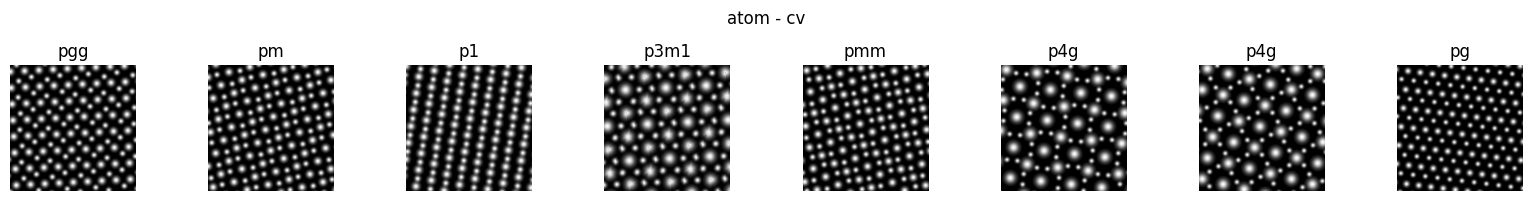

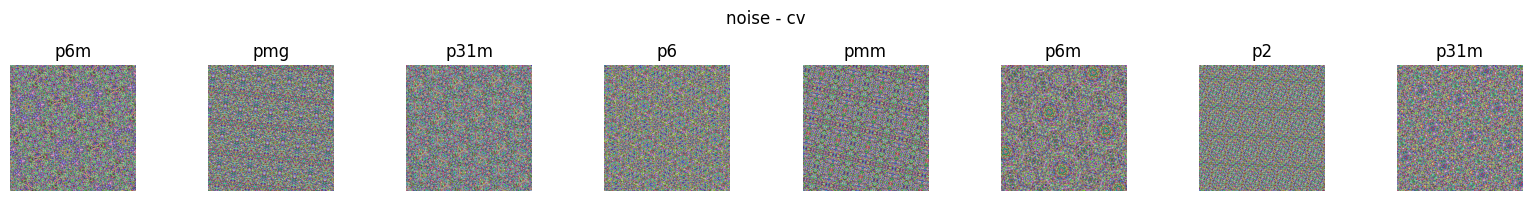

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb

import sys
sys.path.append('../../src/benchmark/')
sys.path.append('../../src/utils/')
from build_model import resnet50_
from utils import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from trainer import Trainer, accuracy

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)
bs = 3800

# # atom
atom_ds = hdf5_dataset('../../datasets/atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_dl = DataLoader(atom_ds, batch_size=bs, shuffle=False, num_workers=4)
viz_dataloader(atom_dl, label_converter=label_converter, title='atom - cv')

# # noise
noise_ds = hdf5_dataset('../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='noise', transform=transforms.ToTensor())
noise_dl = DataLoader(noise_ds, batch_size=bs, shuffle=False, num_workers=4)
viz_dataloader(noise_dl, label_converter=label_converter, title='noise - cv')

### 1K training dataset size 

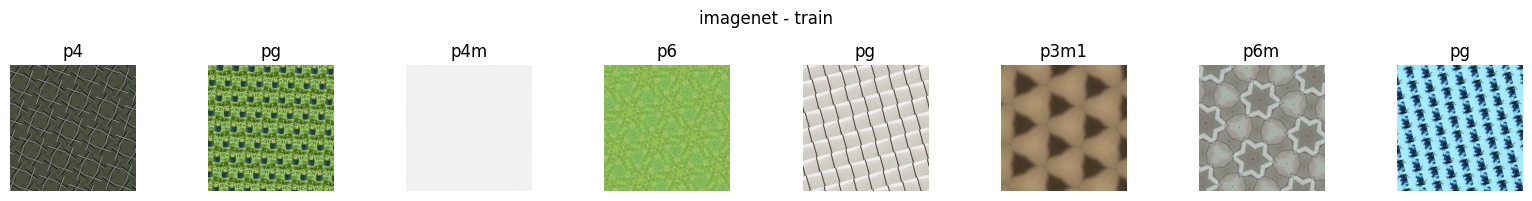

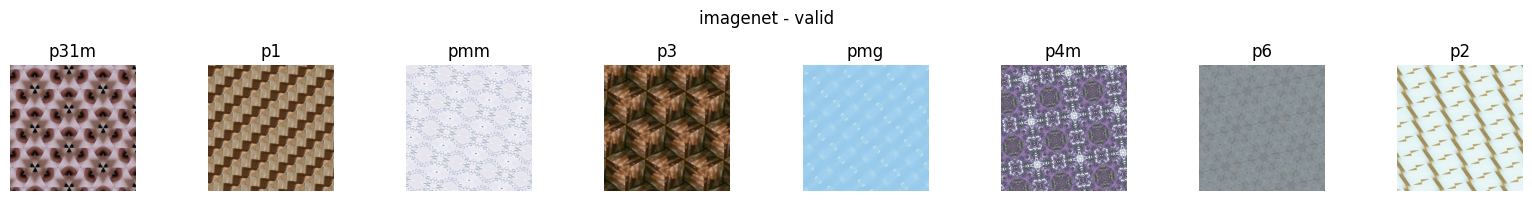

In [5]:
# imagenet
imagenet_ds = hdf5_dataset('../../datasets/imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
_, imagenet_ds = split_train_valid(imagenet_ds, 0.9999, seed=42)
train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8, seed=42)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')
valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

In [3]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)
model = torch.nn.DataParallel(model, device_ids=[3,4,5,6,7,9])
device = torch.device('cuda:3')
# model

torch.Size([2, 17])


In [4]:
config = {'dataset': '1k datasets',
          'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
          'optimizer': 'Adam',
          'scheduler': 'OneCycleLR'}
NAME = '09022024-resnet50-dataset_v5_size-1k'
wandb.login()
proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='dataset_v5_size_vs_records', save_code=True, config=config, resume='allow')
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [6]:
lr = 1e-3
per_epoch = 100
epoch_start = 0
epochs = 50000
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
metrics = [accuracy]  # You can add more metrics if needed
trainer = Trainer(model=model, loss_func=loss_func, optimizer=optimizer, metrics=metrics, scheduler=scheduler, 
                  device=device, save_per_epochs=per_epoch, model_path=f'../../saved_models/{NAME}/', early_stopping_patience=2000)

history = trainer.train(train_dl=train_dl, epochs=epochs, epoch_start=epoch_start, valid_per_epochs=per_epoch,
                        valid_dl_list=[valid_dl, atom_dl, noise_dl], valid_dl_names=['', 'atom', 'noise'], tracking=True)
wandb.finish()

Epoch 1/50000


100%|██████████| 1/1 [00:07<00:00,  7.38s/it]


train_loss: 3.1283, train_accuracy: 7.23%
Epoch 2/50000


100%|██████████| 1/1 [00:02<00:00,  2.02s/it]


train_loss: 3.1360, train_accuracy: 5.60%
Epoch 3/50000


...

100%|██████████| 1/1 [00:02<00:00,  2.07s/it]


train_loss: 2.4496, train_accuracy: 23.22%
Epoch 174/50000


100%|██████████| 1/1 [00:01<00:00,  1.87s/it]


train_loss: 2.5365, train_accuracy: 20.89%
Epoch 175/50000


  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
trainer.plot_training_metrics()

### 10K dataset

In [ ]:
# imagenet
imagenet_ds = hdf5_dataset('../../datasets/imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
_, imagenet_ds = split_train_valid(imagenet_ds, 0.999, seed=42)
print(len(imagenet_ds))
train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8, seed=42)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')
valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

In [ ]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)
model.load_state_dict(torch.load('../../saved_models/09022024-resnet50-dataset_v5_size-10k-new/model_epoch_200.pth'))
model = torch.nn.DataParallel(model, device_ids=[7,9])
device = torch.device('cuda:7')
# model

In [ ]:
config = {'dataset': '10k datasets',
          'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
          'optimizer': 'Adam',
          'scheduler': 'OneCycleLR'}
NAME = '09022024-resnet50-dataset_v5_size-10k-new'
wandb.login()
proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='dataset_v5_size', save_code=True, config=config)
config = wandb.config

In [ ]:
lr = 1e-3
per_epoch = 20
epoch_start = 0
epochs = 200
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
metrics = [accuracy]  # You can add more metrics if needed
trainer = Trainer(model=model, loss_func=loss_func, optimizer=optimizer, metrics=metrics, scheduler=scheduler, 
                  device=device, save_per_epochs=per_epoch, model_path=f'../../saved_models/{NAME}/', early_stopping_patience=None)

history = trainer.train(train_dl=train_dl, epochs=epochs, epoch_start=epoch_start, valid_per_epochs=per_epoch,
                        valid_dl_list=[valid_dl, atom_dl, noise_dl], valid_dl_names=['', 'atom', 'noise'], tracking=True)
wandb.finish()

In [ ]:
trainer.plot_training_metrics()

In [ ]:
lr = 1e-3
per_epoch = 20
epoch_start = 200
epochs = 300
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
metrics = [accuracy]  # You can add more metrics if needed
trainer = Trainer(model=model, loss_func=loss_func, optimizer=optimizer, metrics=metrics, scheduler=scheduler, 
                  device=device, save_per_epochs=per_epoch, model_path=f'../../saved_models/{NAME}/', early_stopping_patience=None)

history = trainer.train(train_dl=train_dl, epochs=epochs, epoch_start=epoch_start, valid_per_epochs=per_epoch,
                        valid_dl_list=[valid_dl, atom_dl, noise_dl], valid_dl_names=['', 'atom', 'noise'], tracking=True)
wandb.finish()

In [ ]:
trainer.plot_training_metrics()

### 100K dataset

In [ ]:
# imagenet
imagenet_ds = hdf5_dataset('../../datasets/imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
_, imagenet_ds = split_train_valid(imagenet_ds, 0.99, seed=42)
print(len(imagenet_ds))
train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8, seed=42)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')
valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

In [ ]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)
model.load_state_dict(torch.load('../../saved_models/09022024-resnet50-dataset_v5_size-100k/model_epoch_50.pth'))
model = torch.nn.DataParallel(model, device_ids=[7,9])
device = torch.device('cuda:7')
# model

In [ ]:
config = {'dataset': '100k datasets',
          'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
          'optimizer': 'Adam',
          'scheduler': 'OneCycleLR'}
NAME = '09022024-resnet50-dataset_v5_size-100k'
wandb.login()
proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='dataset_v5_size', save_code=True, config=config)
config = wandb.config

In [ ]:
lr = 1e-3
per_epoch = 5
epoch_start = 0
epochs = 50
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
metrics = [accuracy]  # You can add more metrics if needed
trainer = Trainer(model=model, loss_func=loss_func, optimizer=optimizer, metrics=metrics, scheduler=scheduler, 
                  device=device, save_per_epochs=per_epoch, model_path=f'../../saved_models/{NAME}/', early_stopping_patience=None)

history = trainer.train(train_dl=train_dl, epochs=epochs, epoch_start=epoch_start, valid_per_epochs=per_epoch,
                        valid_dl_list=[valid_dl, atom_dl, noise_dl], valid_dl_names=['', 'atom', 'noise'], tracking=True)
wandb.finish()

In [ ]:
lr = 1e-3
per_epoch = 5
epoch_start = 50
epochs = 50
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
metrics = [accuracy]  # You can add more metrics if needed
trainer = Trainer(model=model, loss_func=loss_func, optimizer=optimizer, metrics=metrics, scheduler=scheduler, 
                  device=device, save_per_epochs=per_epoch, model_path=f'../../saved_models/{NAME}/', early_stopping_patience=None)

history = trainer.train(train_dl=train_dl, epochs=epochs, epoch_start=epoch_start, valid_per_epochs=per_epoch,
                        valid_dl_list=[valid_dl, atom_dl, noise_dl], valid_dl_names=['', 'atom', 'noise'], tracking=True)
wandb.finish()

In [ ]:
trainer.plot_training_metrics()

### 500K dataset

In [ ]:
# imagenet
imagenet_ds = hdf5_dataset('../../datasets/imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
_, imagenet_ds = split_train_valid(imagenet_ds, 0.951, seed=42) # model can't process single image batch
print(len(imagenet_ds))
train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8, seed=42)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')
valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

In [ ]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)
model.load_state_dict(torch.load('../../saved_models/09022024-resnet50-dataset_v5_size-500k/model_epoch_10.pth'))
model = torch.nn.DataParallel(model, device_ids=[5,6,7,9])
device = torch.device('cuda:5')
# model

In [ ]:
config = {'dataset': '500k datasets',
          'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
          'optimizer': 'Adam',
          'scheduler': 'OneCycleLR'}
NAME = '09022024-resnet50-dataset_v5_size-500k'
wandb.login()
proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='dataset_v5_size', save_code=True, config=config, resume='must')
config = wandb.config

In [ ]:
lr = 1e-3
per_epoch = 5
epoch_start = 0
epochs = 100
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
metrics = [accuracy]  # You can add more metrics if needed
trainer = Trainer(model=model, loss_func=loss_func, optimizer=optimizer, metrics=metrics, scheduler=scheduler, 
                  device=device, save_per_epochs=per_epoch, model_path=f'../../saved_models/{NAME}/', early_stopping_patience=None)

history = trainer.train(train_dl=train_dl, epochs=epochs, epoch_start=epoch_start, valid_per_epochs=per_epoch,
                        valid_dl_list=[valid_dl, atom_dl, noise_dl], valid_dl_names=['', 'atom', 'noise'], tracking=True)
wandb.finish()

In [ ]:
lr = 1e-3
per_epoch = 5
epoch_start = 10
epochs = 40
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
metrics = [accuracy]  # You can add more metrics if needed
trainer = Trainer(model=model, loss_func=loss_func, optimizer=optimizer, metrics=metrics, scheduler=scheduler, 
                  device=device, save_per_epochs=per_epoch, model_path=f'../../saved_models/{NAME}/', early_stopping_patience=5)

history = trainer.train(train_dl=train_dl, epochs=epochs, epoch_start=epoch_start, valid_per_epochs=per_epoch,
                        valid_dl_list=[valid_dl, atom_dl, noise_dl], valid_dl_names=['', 'atom', 'noise'], tracking=True)
wandb.finish()

In [ ]:
lr = 1e-3
per_epoch = 5
epoch_start = 50
epochs = 30
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
metrics = [accuracy]  # You can add more metrics if needed
trainer = Trainer(model=model, loss_func=loss_func, optimizer=optimizer, metrics=metrics, scheduler=scheduler, 
                  device=device, save_per_epochs=per_epoch, model_path=f'../../saved_models/{NAME}/', early_stopping_patience=5)

history = trainer.train(train_dl=train_dl, epochs=epochs, epoch_start=epoch_start, valid_per_epochs=per_epoch,
                        valid_dl_list=[valid_dl, atom_dl, noise_dl], valid_dl_names=['', 'atom', 'noise'], tracking=True)
wandb.finish()

### 1 million dataset

In [ ]:
# imagenet
imagenet_ds = hdf5_dataset('../../datasets/imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
_, imagenet_ds = split_train_valid(imagenet_ds, 0.9, seed=42)
print(len(imagenet_ds))
train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8, seed=42)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')
valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

In [ ]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)
model = torch.nn.DataParallel(model, device_ids=[5,6,7,9])
device = torch.device('cuda:5')
# model

In [ ]:
config = {'dataset': '1m datasets',
          'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
          'optimizer': 'Adam',
          'scheduler': 'OneCycleLR'}
NAME = '09022024-resnet50-dataset_v5_size-1m'
wandb.login()
proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='dataset_v5_size', save_code=True, config=config)
config = wandb.config

In [ ]:
lr = 1e-3
per_epoch = 5
epoch_start = 0
epochs = 50
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
metrics = [accuracy]  # You can add more metrics if needed
trainer = Trainer(model=model, loss_func=loss_func, optimizer=optimizer, metrics=metrics, scheduler=scheduler, 
                  device=device, save_per_epochs=per_epoch, model_path=f'../../saved_models/{NAME}/', early_stopping_patience=None)

history = trainer.train(train_dl=train_dl, epochs=epochs, epoch_start=epoch_start, valid_per_epochs=per_epoch,
                        valid_dl_list=[valid_dl, atom_dl, noise_dl], valid_dl_names=['', 'atom', 'noise'], tracking=True)
wandb.finish()

In [ ]:
trainer.plot_training_metrics()

### 2 million dataset

In [ ]:
# imagenet
imagenet_ds = hdf5_dataset('../../datasets/imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
_, imagenet_ds = split_train_valid(imagenet_ds, 0.8, seed=42)
print(len(imagenet_ds))
train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8, seed=42)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=8)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')
valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, num_workers=8)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

In [ ]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)
model = torch.nn.DataParallel(model, device_ids=[5,6,7,9])
device = torch.device('cuda:5')
# model

In [ ]:
config = {'dataset': '2m datasets',
          'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
          'optimizer': 'Adam',
          'scheduler': 'OneCycleLR'}
NAME = '09022024-resnet50-dataset_v5_size-2m'
wandb.login()
proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='dataset_v5_size', save_code=True, config=config)
config = wandb.config

In [ ]:
lr = 1e-3
per_epoch = 2
epoch_start = 0
epochs = 50
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
metrics = [accuracy]  # You can add more metrics if needed
trainer = Trainer(model=model, loss_func=loss_func, optimizer=optimizer, metrics=metrics, scheduler=scheduler, 
                  device=device, save_per_epochs=per_epoch, model_path=f'../../saved_models/{NAME}/', early_stopping_patience=5)

history = trainer.train(train_dl=train_dl, epochs=epochs, epoch_start=epoch_start, valid_per_epochs=per_epoch,
                        valid_dl_list=[valid_dl, atom_dl, noise_dl], valid_dl_names=['', 'atom', 'noise'], tracking=True)
wandb.finish()

In [ ]:
trainer.plot_training_metrics()

### 5 million dataset

In [ ]:
# imagenet
imagenet_ds = hdf5_dataset('../../datasets/imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
_, imagenet_ds = split_train_valid(imagenet_ds, 0.5, seed=42)
print(len(imagenet_ds))
train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8, seed=42)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=8)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')
valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, num_workers=8)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

In [ ]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)
model = torch.nn.DataParallel(model, device_ids=[5,6,7,9])
device = torch.device('cuda:5')
# model

In [ ]:
config = {'dataset': '5m datasets',
          'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
          'optimizer': 'Adam',
          'scheduler': 'OneCycleLR'}
NAME = '09022024-resnet50-dataset_v5_size-5m'
wandb.login()
proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='dataset_v5_size', save_code=True, config=config, resume='must')
config = wandb.config

In [ ]:
lr = 1e-3
per_epoch = 2
epoch_start = 0
epochs = 50
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
metrics = [accuracy]  # You can add more metrics if needed
trainer = Trainer(model=model, loss_func=loss_func, optimizer=optimizer, metrics=metrics, scheduler=scheduler, 
                  device=device, save_per_epochs=per_epoch, model_path=f'../../saved_models/{NAME}/', early_stopping_patience=5)

history = trainer.train(train_dl=train_dl, epochs=epochs, epoch_start=epoch_start, valid_per_epochs=per_epoch,
                        valid_dl_list=[valid_dl, atom_dl, noise_dl], valid_dl_names=['', 'atom', 'noise'], tracking=True)
wandb.finish()

In [ ]:
trainer.early_stopping_patience = None

In [ ]:
per_epoch = 2
epoch_start = 10
epochs = 40
history = trainer.train(train_dl=train_dl, epochs=epochs, epoch_start=epoch_start, valid_per_epochs=per_epoch,
                        valid_dl_list=[valid_dl, atom_dl, noise_dl], valid_dl_names=['', 'atom', 'noise'], tracking=True)

In [ ]:
wandb.finish()
trainer.plot_training_metrics()

### full size dataset - 10 million

In [ ]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
imagenet_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8)
train_dl = DataLoader(train_ds, batch_size=300, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')
valid_dl = DataLoader(valid_ds, batch_size=300, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# # atom
atom_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_dl = DataLoader(atom_ds, batch_size=300, shuffle=False, num_workers=4)
viz_dataloader(atom_dl, label_converter=label_converter, title='atom - cv')

# # noise
noise_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='noise', transform=transforms.ToTensor())
noise_dl = DataLoader(noise_ds, batch_size=300, shuffle=False, num_workers=4)
viz_dataloader(noise_dl, label_converter=label_converter, title='noise - cv')

In [ ]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)
model = torch.nn.DataParallel(model, device_ids=[7,9])
device = torch.device('cuda:7')
# model

In [ ]:
config = {
    'dataset': '10 million datasets',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = '05242024-benchmark-resnet50_from_scratch-v5_10m'

In [ ]:
wandb.login()
proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

In [ ]:
device = torch.device('cuda:0')
lr = 1e-3
start = 0
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, cv_dl_list=[atom_dl, noise_dl], cv_name_list=['atom', 'noise'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir='../../../saved_models/', tracking=True)